<center>

# Drug-Related Deaths Compared to Availability of Harm Reduction Services

## Merging the Data, Storing in a Database, and Visualizing Data

Jess South<br>
April 4, 2026<br>

</center>

## Data Preparation

In [1]:
# Imports
import pandas as pd

In [2]:
# Import data
# Factors
df_syringe_legality = pd.read_csv('../syringe_exchange_legality.csv')
df_syringe_prog_ct = pd.read_csv('../num_syringe_programs.csv')
df_methadone_cov = pd.read_csv('../medicaid_methodone_coverage.csv')
df_fqhcs = pd.read_csv('../fqhcs.csv')

# Outcomes
df_drug_death_rate = pd.read_csv('../drug_death_rate.csv')
df_drugdep = pd.read_csv('../drugdep.csv')

In [3]:
df_drug_death_rate.head()

,STATE,STATEABBREVIATION,STATEFP,INDICATOR,YEAR,VALUE
0,Alabama,AL,1,drugdeathrate,1999,3.81
1,Alaska,AK,2,drugdeathrate,1999,7.36
2,Arizona,AZ,4,drugdeathrate,1999,10.17
3,Arkansas,AR,5,drugdeathrate,1999,4.26
4,California,CA,6,drugdeathrate,1999,7.95


In [4]:
# Begin assembling single dataframe
df_ddr_2019 = df_drug_death_rate[df_drug_death_rate['YEAR'] == 2019]
df_ddr_2019 = df_ddr_2019.rename(columns={'VALUE': 'drugdeathrate_2019'})
df_ddr_2019 = df_ddr_2019.drop(['STATEFP', 'STATEABBREVIATION', 'INDICATOR', 'YEAR'], axis=1)
df_ddr_2019.head()

,STATE,drugdeathrate_2019
1040,Alabama,15.66
1041,Alaska,18.04
1042,Arizona,26.20
1043,Arkansas,12.86
1044,California,15.69


In [5]:
df_ddr_2014 = df_drug_death_rate[df_drug_death_rate['YEAR'] == 2014]
df_ddr_2014 = df_ddr_2014.rename(columns={'VALUE': 'drugdeathrate_2014'})
df_ddr_2014 = df_ddr_2014.drop(['STATEFP', 'STATEABBREVIATION', 'INDICATOR', 'YEAR'], axis=1)
df_ddr_2014.head()

,STATE,drugdeathrate_2014
780,Alabama,14.91
781,Alaska,16.83
782,Arizona,17.99
783,Arkansas,12.00
784,California,11.65


In [6]:
df_ddr_2017 = df_drug_death_rate[df_drug_death_rate['YEAR'] == 2017]
df_ddr_2017 = df_ddr_2017.rename(columns={'VALUE': 'drugdeathrate_2017'})
df_ddr_2017 = df_ddr_2017.drop(['STATEFP', 'STATEABBREVIATION', 'INDICATOR', 'YEAR'], axis=1)
df_ddr_2017.head()

,STATE,drugdeathrate_2017
936,Alabama,17.13
937,Alaska,19.87
938,Arizona,21.83
939,Arkansas,14.85
940,California,12.31


In [7]:
# Add drug dependency - ONLY contains drug dependencies from 2014
df_drugdep = df_drugdep.rename(columns={'VALUE': 'drugdep_2014'})
df_drugdep = df_drugdep.drop(['STATEABBREVIATION', 'STATEFP', 'INDICATOR', 'YEAR'], axis=1)
df_drugdep.head()

,STATE,drugdep_2014
0,United States,0.0270
1,Alabama,0.0253
2,Alaska,0.0306
3,Arizona,0.0303
4,Arkansas,0.0267


In [8]:
# Add contributors: syringe program legality (2021)
# df_sl_19 = df_syringe_legality[df_syringe_legality['YEAR'] == 2019] # Returns no entries
df_syringe_legality['VALUE'].mask(df_syringe_legality['VALUE'] == 1, 'Not Legal', inplace=True)
df_syringe_legality['VALUE'].mask(df_syringe_legality['VALUE'] == 2, 'Locally Permitted', inplace=True)
df_syringe_legality['VALUE'].mask(df_syringe_legality['VALUE'] == 3, 'Legal', inplace=True)
df_slegal = df_syringe_legality.rename(columns={'VALUE': 'SSP_legality_2021'})
df_slegal = df_slegal.drop(['STATEFP', 'STATEABBREVIATION', 'INDICATOR', 'YEAR'], axis=1)
df_slegal.head()

/tmp/ipykernel_813552/2485035129.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_syringe_legality['VALUE'].mask(df_syringe_legality['VALUE'] == 1, 'Not Legal', inplace=True)
/tmp/ipykernel_813552/2485035129.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Not Legal' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_syringe_legality['VALUE'].mask(df_syringe_legality['VALUE'] == 1, 'Not Legal',

,STATE,SSP_legality_2021
0,Alabama,Not Legal
1,Alaska,Locally Permitted
2,Arizona,Legal
3,Arkansas,Not Legal
4,California,Legal


In [9]:
# Syringe exchange program count, 2023
df_spct_2023 = df_syringe_prog_ct[df_syringe_prog_ct['YEAR'] == 2023]
df_spct_2023 = df_spct_2023.rename(columns={'VALUE': 'num_SSPs_2023'})
df_spct_2023 = df_spct_2023.drop(['STATEABBREVIATION', 'STATEFP', 'INDICATOR', 'YEAR'], axis=1)
df_spct_2023.head()

,STATE,num_SSPs_2023
0,United States,966.0
1,Alabama,2.0
2,Alaska,7.0
3,Arizona,25.0
4,Arkansas,4.0


In [10]:
# Syringe exchange program count, 2024
df_spct_2024 = df_syringe_prog_ct[df_syringe_prog_ct['YEAR'] == 2024]
df_spct_2024 = df_spct_2024.rename(columns={'VALUE': 'num_SSPs_2024'})
df_spct_2024 = df_spct_2024.drop(['STATEABBREVIATION', 'STATEFP', 'INDICATOR', 'YEAR'], axis=1)
df_spct_2024.head()

,STATE,num_SSPs_2024
58,United States,849.0
59,Alabama,1.0
60,Alaska,6.0
61,Arizona,26.0
62,Arkansas,3.0


In [37]:
# State methadone coverage through Medicaid
df_methadone_cov.head()
df_methadone_cov['VALUE'].mask(df_methadone_cov['VALUE'] == 1, 'Not Covered', inplace=True)
df_methadone_cov['VALUE'].mask(df_methadone_cov['VALUE'] == 2, 'Covered', inplace=True)
df_mmcov = df_methadone_cov.rename(columns={'VALUE': 'med_meth_2017'})
df_mmcov = df_mmcov.drop(['STATEABBREVIATION', 'STATEFP', 'INDICATOR', 'YEAR'], axis=1)
df_mmcov.head()

/tmp/ipykernel_813552/2654077851.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_methadone_cov['VALUE'].mask(df_methadone_cov['VALUE'] == 1, 'Not Covered', inplace=True)
/tmp/ipykernel_813552/2654077851.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Not Covered' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_methadone_cov['VALUE'].mask(df_methadone_cov['VALUE'] == 1, 'Not Covered', inpla

,STATE,med_meth_2017
0,Alabama,Not Covered
1,Alaska,Covered
2,Arizona,Covered
3,Arkansas,NaN
4,California,Covered


In [38]:
# Merge dfs
df = pd.merge(df_ddr_2014, df_ddr_2017, on='STATE', how='inner')
df = pd.merge(df, df_ddr_2019, on='STATE', how='inner')
df = pd.merge(df, df_drugdep, on='STATE', how='inner')
df = pd.merge(df, df_slegal, on='STATE', how='inner')
df = pd.merge(df, df_spct_2023, on='STATE', how='inner')
df = pd.merge(df, df_spct_2024, on='STATE', how='inner')
df = pd.merge(df, df_mmcov, on='STATE', how='inner')
df.head()

,STATE,drugdeathrate_2014,drugdeathrate_2017,drugdeathrate_2019,drugdep_2014,SSP_legality_2021,num_SSPs_2023,num_SSPs_2024,med_meth_2017
0,Alabama,14.91,17.13,15.66,0.0253,Not Legal,2.0,1.0,Not Covered
1,Alaska,16.83,19.87,18.04,0.0306,Locally Permitted,7.0,6.0,Covered
2,Arizona,17.99,21.83,26.20,0.0303,Legal,25.0,26.0,Covered
3,Arkansas,12.00,14.85,12.86,0.0267,Not Legal,4.0,3.0,NaN
4,California,11.65,12.31,15.69,0.0289,Legal,99.0,95.0,Covered


## Graphing

In [43]:
# Imports
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

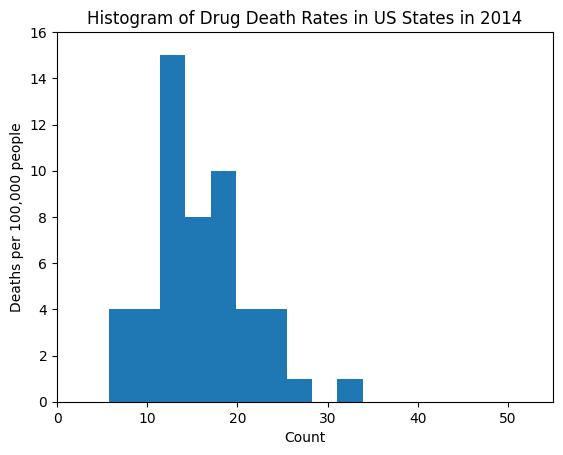

In [49]:
# Plot histo of drug death rates
plt.hist(df['drugdeathrate_2014'])
plt.title('Histogram of Drug Death Rates in US States in 2014')
plt.xlabel('Count')
plt.ylabel('Deaths per 100,000 people')

ax = plt.gca()
ax.set_xlim([0, 55])
ax.set_ylim([0, 16])

plt.savefig('./histogram_deathrates_2014.png')
plt.show()

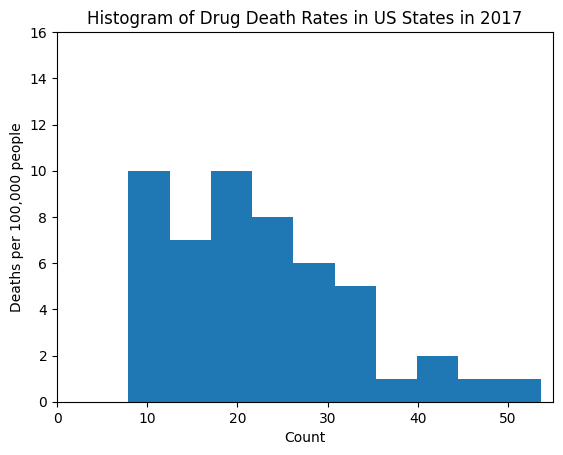

In [50]:
# Plot histo of drug death rates
plt.hist(df['drugdeathrate_2017'])
plt.title('Histogram of Drug Death Rates in US States in 2017')
plt.xlabel('Count')
plt.ylabel('Deaths per 100,000 people')

ax = plt.gca()
ax.set_xlim([0, 55])
ax.set_ylim([0, 16])

plt.savefig('./histogram_deathrates_2017.png')
plt.show()

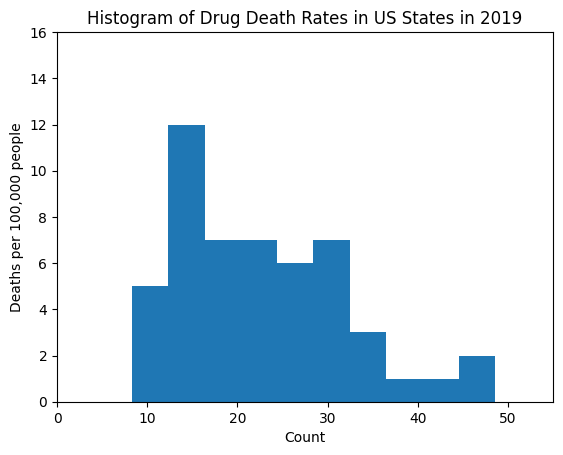

In [51]:
# Plot histo of drug death rates
plt.hist(df['drugdeathrate_2019'])
plt.title('Histogram of Drug Death Rates in US States in 2019')
plt.xlabel('Count')
plt.ylabel('Deaths per 100,000 people')

ax = plt.gca()
ax.set_xlim([0, 55])
ax.set_ylim([0, 16])

plt.savefig('./histogram_deathrates_2019.png')
plt.show()

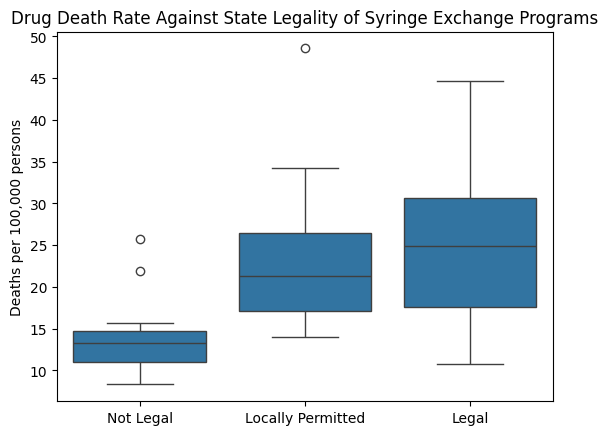

In [58]:
sns.boxplot(x=df['SSP_legality_2021'], y=df['drugdeathrate_2019'])
plt.title('Drug Death Rate Against State Legality of Syringe Exchange Programs')
plt.xlabel('')
plt.ylabel('Deaths per 100,000 persons')

plt.savefig('./boxplot_death_legality.png')
plt.show()

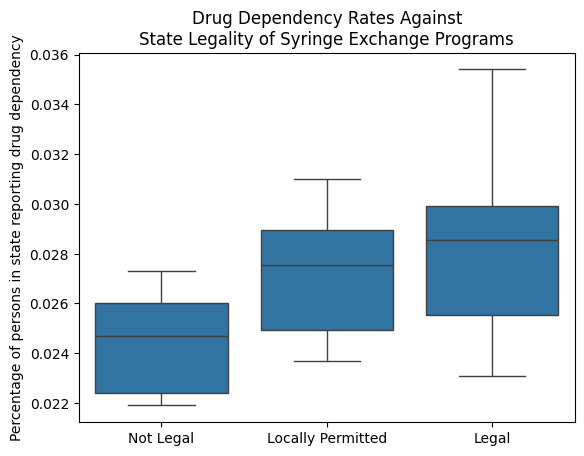

In [59]:
sns.boxplot(x=df['SSP_legality_2021'], y=df['drugdep_2014'])
plt.title('Drug Dependency Rates Against\nState Legality of Syringe Exchange Programs')
plt.xlabel('')
plt.ylabel('Percentage of persons in state reporting drug dependency')

plt.savefig('./boxplot_dependency_legality.png')
plt.show()

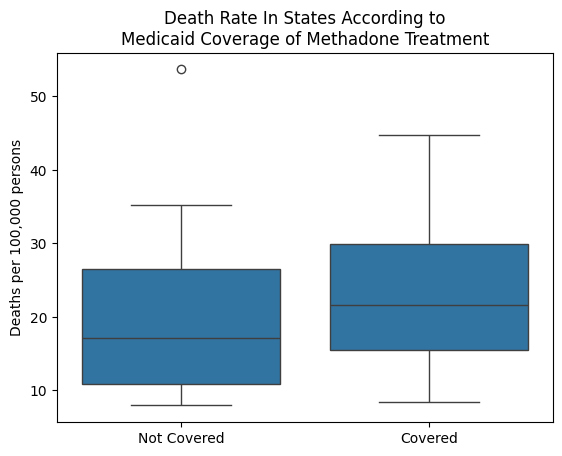

In [62]:
sns.boxplot(x=df['med_meth_2017'], y=df['drugdeathrate_2017'])
plt.title('Death Rate In States According to\nMedicaid Coverage of Methadone Treatment')
plt.xlabel('')
plt.ylabel('Deaths per 100,000 persons')

plt.savefig('./boxplot_death_coverage.png')
plt.show()

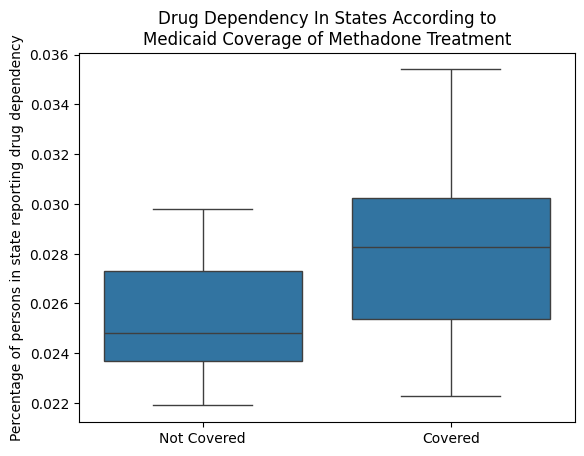

In [63]:
sns.boxplot(x=df['med_meth_2017'], y=df['drugdep_2014'])
plt.title('Drug Dependency In States According to\nMedicaid Coverage of Methadone Treatment')
plt.xlabel('')
plt.ylabel('Percentage of persons in state reporting drug dependency')

plt.savefig('./boxplot_dependency_coverage.png')
plt.show()

556.1181055231586


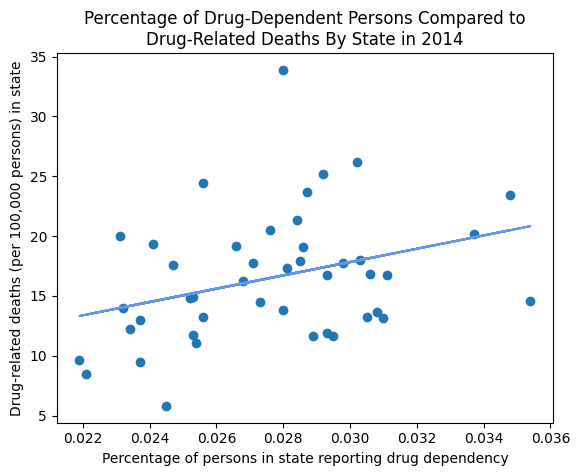

In [47]:
# Scatterplots
dfdna = df.dropna()
fig, ax = plt.subplots()
ax.scatter('drugdep_2014',
           'drugdeathrate_2014',
           data=dfdna,
           marker='o')

# line of best fit
slope, intercept = np.polyfit(dfdna['drugdep_2014'], dfdna['drugdeathrate_2014'], 1)
line = slope * dfdna['drugdep_2014'] + intercept
plt.plot(dfdna['drugdep_2014'], line, color='cornflowerblue')
print(slope)


plt.title("Percentage of Drug-Dependent Persons Compared to\nDrug-Related Deaths By State in 2014")
plt.xlabel('Percentage of persons in state reporting drug dependency')
plt.ylabel('Drug-related deaths (per 100,000 persons) in state')
plt.savefig('./scatter_drugdep_deathrate_2014.png')
plt.show()

-0.016195119410672087


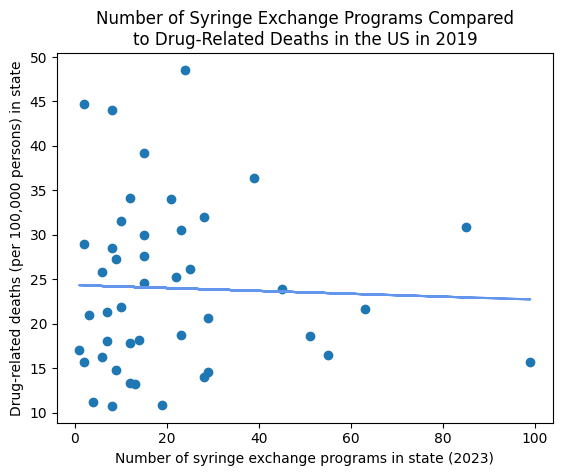

In [65]:
# Scatterplots
dfdna = df.dropna()
fig, ax = plt.subplots()
ax.scatter('num_SSPs_2023',
           'drugdeathrate_2019',
           data=dfdna,
           marker='o')

# line of best fit
slope, intercept = np.polyfit(dfdna['num_SSPs_2023'], dfdna['drugdeathrate_2019'], 1)
line = slope * dfdna['num_SSPs_2023'] + intercept
plt.plot(dfdna['num_SSPs_2023'], line, color='cornflowerblue')
print(slope)

plt.title("Number of Syringe Exchange Programs Compared\nto Drug-Related Deaths in the US in 2019")
plt.xlabel('Number of syringe exchange programs in state (2023)')
plt.ylabel('Drug-related deaths (per 100,000 persons) in state')

plt.savefig('./scatter_sspct_deaths.png')
plt.show()

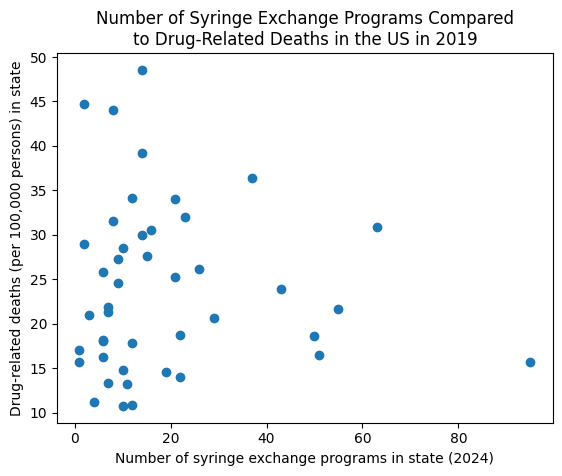

In [33]:
# Scatterplots
dfdna = df.dropna()
fig, ax = plt.subplots()
ax.scatter('num_SSPs_2024',
           'drugdeathrate_2019',
           data=dfdna,
           marker='o')
plt.title("Number of Syringe Exchange Programs Compared\nto Drug-Related Deaths in the US in 2019")
plt.xlabel('Number of syringe exchange programs in state (2024)')
plt.ylabel('Drug-related deaths (per 100,000 persons) in state')
plt.show()